Name: Advik Ganapathy M B
BITS ID: 2026A7PS0354P
Music Genre Classifier

Use your kaggle API token in the cell below, getpass has been used to safeguard your token

In [1]:
from getpass import getpass

kaggle_token = getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token: ··········


The following cell is the only pip install used in this notebook.

In [2]:
!pip install -q kaggle

In [3]:
import os

os.environ["KAGGLE_API_TOKEN"] = kaggle_token
!kaggle datasets list -s gtzan

ref                                                      title                                                 size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------------------------------  ---------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
andradaolteanu/gtzan-dataset-music-genre-classification  GTZAN Dataset - Music Genre Classification      1301492495  2020-03-24 14:05:33.357000         124409        961  0.88235295       
carlthome/gtzan-genre-collection                         GTZAN Genre Collection                          1225975597  2019-10-30 07:38:06.633000          10090         77  0.8125           
lnicalo/gtzan-musicspeech-collection                     GTZAN music/speech collection                    296835448  2017-10-24 12:52:44.587000           2913         43  0.625            
mantasu/gtzan-stems                                    

In [4]:
!mkdir -p /content/gtzan
!kaggle datasets download -d andradaolteanu/gtzan-dataset-music-genre-classification -p /content/gtzan

Dataset URL: https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification
License(s): other
gtzan-dataset-music-genre-classification.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
!unzip -q /content/gtzan/gtzan-dataset-music-genre-classification.zip -d /content/gtzan

replace /content/gtzan/Data/features_30_sec.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [6]:
!ls /content/gtzan
!ls /content/gtzan/Data
!ls /content/gtzan/Data/genres_original
!ls /content/gtzan/Data/genres_original/blues

Data  gtzan-dataset-music-genre-classification.zip
features_30_sec.csv  features_3_sec.csv  genres_original  images_original
blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock
blues.00000.wav  blues.00025.wav  blues.00050.wav  blues.00075.wav
blues.00001.wav  blues.00026.wav  blues.00051.wav  blues.00076.wav
blues.00002.wav  blues.00027.wav  blues.00052.wav  blues.00077.wav
blues.00003.wav  blues.00028.wav  blues.00053.wav  blues.00078.wav
blues.00004.wav  blues.00029.wav  blues.00054.wav  blues.00079.wav
blues.00005.wav  blues.00030.wav  blues.00055.wav  blues.00080.wav
blues.00006.wav  blues.00031.wav  blues.00056.wav  blues.00081.wav
blues.00007.wav  blues.00032.wav  blues.00057.wav  blues.00082.wav
blues.00008.wav  blues.00033.wav  blues.00058.wav  blues.00083.wav
blues.00009.wav  blues.00034.wav  blues.00059.wav  blues.00084.wav
blues.00010.wav  blues.00035.wav  blues.00060.wav  blues.00085.wav
blues.00011.wav  blues.00036.wav  blues.00061.wav  blues.00086.wav

The following few cells show the waveform, spectrogram and mel spectrogram for the first audio file


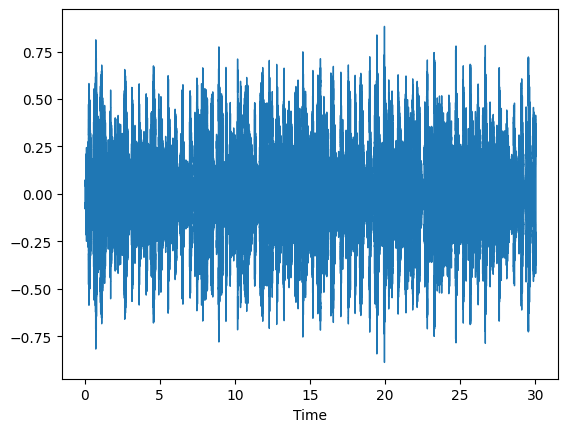

In [7]:
import librosa
import matplotlib.pyplot as plt

waveform,sample_rate=librosa.load("/content/gtzan/Data/genres_original/blues/blues.00000.wav")
librosa.display.waveshow(waveform)


Text(0, 0.5, 'Frequency')

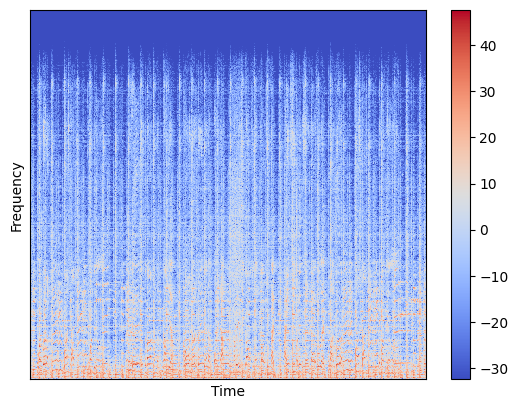

In [8]:
import numpy as np
np.random.seed(42)
stft=librosa.stft(waveform)
spectrogram=librosa.amplitude_to_db(np.abs(stft))

librosa.display.specshow(spectrogram,sr=sample_rate)
plt.colorbar()
plt.xlabel("Time")
plt.ylabel("Frequency")

Text(0, 0.5, 'Mel Frequency')

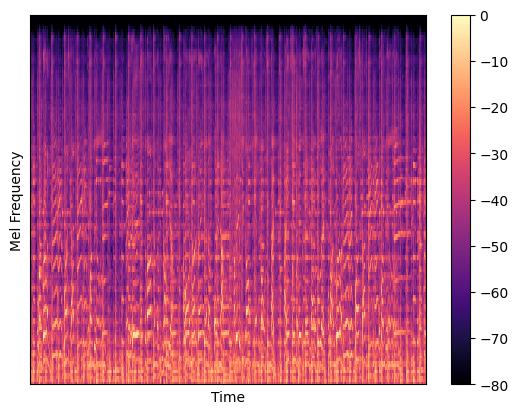

In [9]:
melspectro = librosa.feature.melspectrogram(S=np.abs(stft)**2,sr=sample_rate)
melspectrogramdb = librosa.power_to_db(melspectro,ref=np.max)
librosa.display.specshow(melspectrogramdb,sr=sample_rate)
plt.colorbar()
plt.xlabel("Time")
plt.ylabel("Mel Frequency")

This blues clip seems to have more energy in the lower frequencies. Also there was quite a change from the normal spectrogram to the mel spectrogram. You can see how the mel scale is non linear, showing more resolution to lower frequencies, so the frequency components that were at the bottom in the normal spectrogram are spread out more vertically in the mel spectrogram.

Now I will work on doing this process on all the files and then making the CNN

In [10]:
melspectrograms=[]
labels=[]
file=""
from pathlib import Path
folder = Path("/content/gtzan/Data/genres_original")

for item in folder.iterdir():
  for file in item.glob("*.wav"):
    try:
      waveform_element,sample_rate_element=librosa.load(file)
      stft_element=librosa.stft(waveform_element)
      melspectro_element = librosa.feature.melspectrogram(S=np.abs(stft_element)**2,sr=sample_rate_element)
      melspectrogramdb_element = librosa.power_to_db(melspectro_element,ref=np.max)
      melspectrogramdb_element = np.clip(melspectrogramdb_element,-80,0)
      melspectrograms.append(melspectrogramdb_element)
      labels.append((item.name))
    except Exception:
      print("Corrupted file:",file)




/tmp/ipykernel_12195/363880935.py:10: UserWarning: PySoundFile failed. Trying audioread instead.
  waveform_element,sample_rate_element=librosa.load(file)
/usr/local/lib/python3.13/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Corrupted file: /content/gtzan/Data/genres_original/jazz/jazz.00054.wav


On running the loop, one of the files in the dataset was not working so I put it in a try except block to prevent it from interfering in our code. So from here on we will be working on the remaining 999 files.

In [11]:
print(len(melspectrograms))
print(len(labels))
melspectrograms[0].shape

999
999


(128, 1293)

Making all the mel spectrograms equal in dimensions either by padding or cropping

In [12]:
target_width = 1292

fixed_mels = []

for x in melspectrograms:
    if x.shape[1] >= target_width:
        fixed_mels.append(x[:, :target_width])
    else:
        pad_width = target_width - x.shape[1]
        x_padded = np.pad(x, ((0, 0), (0, pad_width)), mode="constant",constant_values=-80)
        fixed_mels.append(x_padded)

arraymel = np.array(fixed_mels)
print(arraymel.shape)
arraylabels=np.array(labels)
arraylabels[arraylabels=="blues"]=0
arraylabels[arraylabels=="classical"]=1
arraylabels[arraylabels=="country"]=2
arraylabels[arraylabels=="disco"]=3
arraylabels[arraylabels=="hiphop"]=4
arraylabels[arraylabels=="jazz"]=5
arraylabels[arraylabels=="metal"]=6
arraylabels[arraylabels=="pop"]=7
arraylabels[arraylabels=="reggae"]=8
arraylabels[arraylabels=="rock"]=9


(999, 128, 1292)


In [13]:
#splittig data using sklearn
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(arraymel,arraylabels,test_size=0.2,random_state=42,stratify=arraylabels)
y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

In [14]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
X_train = (X_train + 80) / 80
X_test = (X_test + 80) / 80

Start of architecture


In [15]:
import tensorflow as tf
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()
model = tf.keras.Sequential()
model.add(tf.keras.Sequential([tf.keras.layers.RandomTranslation(height_factor=0.0,width_factor=0.05,fill_mode="reflect")]))
model.add(tf.keras.layers.Conv2D(filters=16,kernel_size=(3, 3),activation="relu",input_shape=(128, 1292, 1),kernel_regularizer=tf.keras.regularizers.l2(1e-4)))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.add(tf.keras.layers.BatchNormalization())

In [17]:
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.add(tf.keras.layers.Dropout(0.10))

In [20]:
model.add(tf.keras.layers.Conv2D(filters=32,kernel_size=(3, 3),activation="relu",kernel_regularizer=tf.keras.regularizers.l2(1e-4)))

In [21]:
model.add(tf.keras.layers.BatchNormalization())

In [22]:
model.add(tf.keras.layers.MaxPooling2D(pool_size=(2, 2)))

In [23]:
model.add(tf.keras.layers.Dropout(0.15))

In [24]:
model.add(tf.keras.layers.Conv2D(64, (3, 3), activation="relu",kernel_regularizer=tf.keras.regularizers.l2(1e-4)))


In [25]:
model.add(tf.keras.layers.BatchNormalization())

In [26]:
model.add(tf.keras.layers.MaxPooling2D((2, 2)))

In [27]:
model.add(tf.keras.layers.Dropout(0.20))

In [28]:
model.add(tf.keras.layers.Conv2D(128, (3, 3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2, 2)))
model.add(tf.keras.layers.Dropout(0.25))

In [29]:
model.add(tf.keras.layers.GlobalAveragePooling2D())

In [30]:
model.add(tf.keras.layers.Dense(32, activation="relu",kernel_regularizer=tf.keras.regularizers.l2(1e-4)
))

In [31]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model.add(tf.keras.layers.Dropout(0.30))

In [33]:
model.add(tf.keras.layers.Dense(10, activation="softmax"))

In [34]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [35]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),loss="sparse_categorical_crossentropy",metrics=["accuracy"])


In [36]:

history=model.fit(X_train,y_train,epochs=80,batch_size=32,validation_split=0.2)

Epoch 1/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 347ms/step - accuracy: 0.1674 - loss: 2.3852 - val_accuracy: 0.0625 - val_loss: 2.3509
Epoch 2/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - accuracy: 0.2801 - loss: 1.9767 - val_accuracy: 0.0625 - val_loss: 2.4676
Epoch 3/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 308ms/step - accuracy: 0.3365 - loss: 1.8661 - val_accuracy: 0.0625 - val_loss: 2.6391
Epoch 4/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 311ms/step - accuracy: 0.3693 - loss: 1.7578 - val_accuracy: 0.0625 - val_loss: 2.8681
Epoch 5/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 309ms/step - accuracy: 0.4147 - loss: 1.6712 - val_accuracy: 0.0625 - val_loss: 3.0551
Epoch 6/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 312ms/step - accuracy: 0.4053 - loss: 1.6705 - val_accuracy: 0.0625 - val_loss: 3.2347
Epoch 7/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 310ms/step - accuracy: 0.4570 - loss: 1.6215 - val_accuracy: 0.0625 - val_loss: 3.4808
Epoch 8/80
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 314ms/step - accuracy: 0.4523 - loss: 1.5941 - val_accuracy: 0

In [37]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 128, 1292, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 1290, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 1290, 16)  │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 645, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 63, 645, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 643, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 643, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 321, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 321, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 319, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 319, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 159, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 159, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 157, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 157, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 78, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 78, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 306,752 (1.17 MB)

 Trainable params: 102,090 (398.79 KB)

 Non-trainable params: 480 (1.88 KB)

 Optimizer params: 204,182 (797.59 KB)

In [38]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step


In [39]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[15  0  0  1  1  3  0  0  0  0]
 [ 0 19  0  0  0  0  0  0  0  1]
 [ 2  2  8  3  0  0  0  1  1  3]
 [ 0  0  0 17  1  0  0  2  0  0]
 [ 0  0  0  0 17  0  0  2  1  0]
 [ 1  2  0  0  0 16  0  1  0  0]
 [ 0  0  0  0  2  0 17  1  0  0]
 [ 0  0  1  0  2  0  0 17  0  0]
 [ 0  0  0  1  3  1  0  3 12  0]
 [ 1  0  2  3  1  0  2  2  0  9]]


Each i th row shows the guesses made by the model for the i th genre. So the diagonal here shows the correct guesses made by the model for each genre as printed below

In [40]:
label_correct=[0,0,0,0,0,0,0,0,0,0]
labelnames=["blues","classical","country","disco","hiphop","jazz","metal","pop","reggae","rock"]
for i in range(0,10):
  label_correct[i]=cm[i][i]
  print(labelnames[i]+" has ",label_correct[i]," correct predictions")


blues has  15  correct predictions
classical has  19  correct predictions
country has  8  correct predictions
disco has  17  correct predictions
hiphop has  17  correct predictions
jazz has  16  correct predictions
metal has  17  correct predictions
pop has  17  correct predictions
reggae has  12  correct predictions
rock has  9  correct predictions


Training curves:

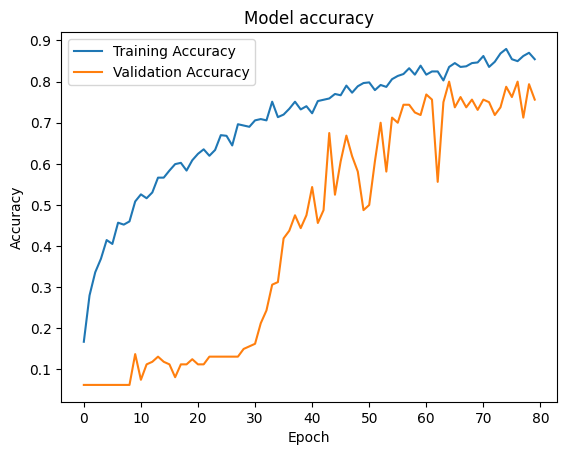

In [41]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(history.history['accuracy'],label="Training Accuracy")
plt.plot(history.history['val_accuracy'],label="Validation Accuracy")
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()

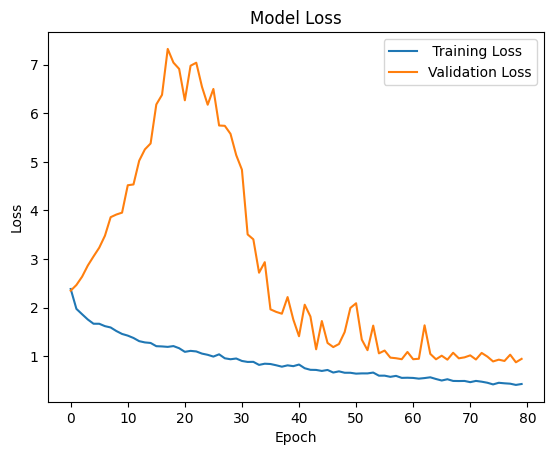

In [42]:
plt.figure()
plt.plot(history.history['loss'],label=" Training Loss")
plt.plot(history.history['val_loss'],label="Validation Loss")
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [43]:
best_val_accuracy = max(history.history["val_accuracy"])
print("Best validation accuracy:", best_val_accuracy)
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", test_accuracy)
print("Parameters:", model.count_params())

Best validation accuracy: 0.800000011920929
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.7350 - loss: 0.8591
Test accuracy: 0.7350000143051147
Parameters: 102570


The above cell shows the final test accuracy along with the highest validation accuracy of the model.
The goal at the start was to raise training accuracy as high as i can at first then fix the overfitting to increase the testing accuracy.
My first architecture: It had 16 filter layer with maxpooling then 32 filter layer with max pooling then a dense layer of 32 (relu) then a dense layer of 10 (using softmax here so that the probabilities sum to 1).

This model worked great on a small dataset but without dropout there was a lot of overfitting. When tested on a dataset of 20 elements, the training accuracy reached 100% each time so my goal of increasing training accuracy first was met. I then did a lot of trial and error with this architecture.




I also tried to use flatten in one of my models, but the parameter count exploded because it connected a single array to a dense layer. There were 1M+ parameters so that idea was discarded. I then replaced flatten with global average pooling 2d layer, this brought back the parameters to a much lower number(6186 parameters). However i had only 10% accuracy here (equivalent to the model taking a random guess for 10 genres)
I added two more convolution layers with 64 filters and 128 filters and increased the epoch count as i realised in the previous runs my training accuracy was still increasing consistently when I would stop training.
I also introduced batch normalization.
This led to a 83.4% training accuracy and 38.8% validation accuracy. So I began fixing the overfitting from here on.

I included dropout layers to reduce the overfitting. Initially I had very aggressive dropouts of 0.4 and 0.5 but later i included smaller more frequent dropouts as seen in the current architecture.


From here on the overall structure remained same but I added more features to optimize it.
I introduced a fixed seed to compare all of these experiments.
Adding L2 and Random Translation to prevent overfitting which helped increase the test accuracy.
I also experimented with the learning rate, here ive used 3*10^-4 (Karpathy constant), I also tried with 10^-4 and 10^-3 also, this gave the best results.

1 issue I faced in testing was that I was relying only on testing accuracy which changes run to run. So I added some set seeds, still the accuracy will vary but not as much as before. I realized this after I had a lucky run with 74% test accuracy on an earlier architecture. I thought it was my architecture changes that caused this but after checking the validation accuracies I realised it was just a lucky run.

The last change in architecture made was dropping all the dropout values by 0.05, this increased the validation and testing accuracy (too aggressive initially) so I have chosen these current values in dropout after experimentation.

I have plotted training curves and explained the confusion matrix in the cells above.

Thank you.
Advik Ganapathy M B
2026A7PS0354P
